In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
import mnists
from psc.models.brightness_based_similarity_detection import PixelStatisticalClassifier
from psc.evaluation import (
    evaluate,
    display_results, 
    display_normalized_confusion_matrix, 
    visualize_class_distributions,
)

In [8]:
mnist_dataset = mnists.MNIST("../datasets/mnist")
x_train = mnist_dataset.train_images()
y_train = mnist_dataset.train_labels()
x_test = mnist_dataset.test_images()
y_test = mnist_dataset.test_labels()

In [9]:
psc = PixelStatisticalClassifier()
psc.fit(x_train, y_train)
print(psc.classes)
print(psc.statistics.shape)

[0 1 2 3 4 5 6 7 8 9]
(28, 28, 10)


In [10]:
results = evaluate(psc, x_test, y_test)
display_results(results)

Class         Accuracy   Precision      Recall    F1 Score
----------------------------------------------------------
0               91.13%      52.54%      98.06%      68.42%
1               88.70%     100.00%       0.44%       0.88%
2               75.17%      28.54%      93.51%      43.73%
3               94.72%      73.54%      74.55%      74.04%
4               92.38%      98.67%      22.71%      36.92%
5               93.88%      74.65%      47.53%      58.08%
6               93.97%      96.34%      38.52%      55.03%
7               96.59%      94.55%      70.91%      81.05%
8               90.41%      50.72%      54.21%      52.41%
9               93.53%      73.45%      56.19%      63.67%
overall         55.24%      74.30%      55.66%      53.42%


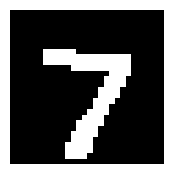

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [35. 14. 34. 32. 30. 32. 24. 49. 33. 37.]

Prediction: 7


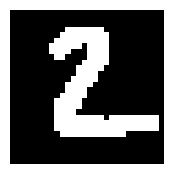

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [51. 25. 60. 51. 24. 49. 47. 24. 46. 28.]

Prediction: 2


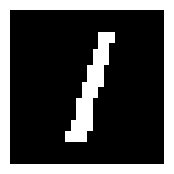

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [16. 24. 27. 23. 14. 20. 19. 17. 24. 17.]

Prediction: 2


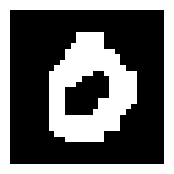

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [101.  26.  77.  67.  52.  75.  71.  61.  65.  59.]

Prediction: 0


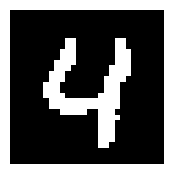

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [38.  8. 41. 28. 39. 31. 32. 32. 33. 35.]

Prediction: 2


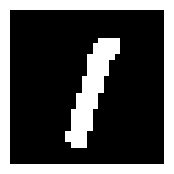

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [23. 33. 37. 33. 21. 29. 24. 26. 35. 26.]

Prediction: 2


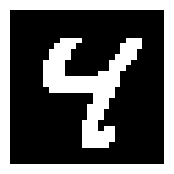

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [33. 15. 37. 39. 40. 40. 30. 39. 41. 40.]

Prediction: 8


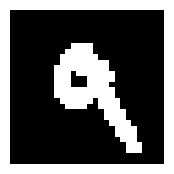

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [34. 20. 39. 39. 38. 42. 38. 34. 40. 43.]

Prediction: 9


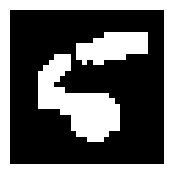

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [62. 27. 65. 43. 47. 54. 52. 40. 52. 47.]

Prediction: 2


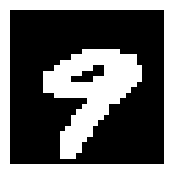

Class        ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']
Dot products [62. 30. 59. 51. 57. 60. 52. 66. 61. 65.]

Prediction: 7


In [11]:
for i in range(10):
    psc.evaluate(x_test[i])

In [12]:
# <<< Analysis >>>
#
# This new model performs considerably worse than the sample counting model.
# The reason for this degradation is not apparent in the results or the evaluation process
# however a brainstorming session with ChatGPT revealed the possible underlying problem:
# similarity index is better obtained using cosine similarity, 
# which uses l2-normalization before applying the dot product, rather than directly using the dot product  
# the problem with min-max normalization is that 
# if Map A has many high-intensity active regions while Map B has only a few, 
# Map A will produce a larger dot product with the test image simply because its vector magnitude is larger, 
# even if Map B matches the specific spatial distribution better.
# L2-normalization solves this by rescaling vectors to unit length, 
# thereby reducing the affects of maps having different vector magnitudes

# <<<  Next step >>>
#
# 1. Use L2-normalization